In [1]:
"""Loss-fraction comparison for the scan60 (trapped_res_weight=10, "With
Delta_res") vs scan62 (trapped_res_weight=0, "Without Delta_res") firm3d
birth-distribution runs, tmax = 1e-1 s.

Produces TWO SEPARATE figures:

  (a) loss fraction vs time (log-log, ms)          -> forpaper/bcrit_loss_time_scan60_62.pdf
  (b) loss fraction vs normalized Bcrit for        -> forpaper/bcrit_loss_bcrit_scan60_62.pdf
      trapped particles, 32 linspace bins, with
      the per-bin count of trapped initial
      conditions on a secondary axis

CONVENTION (norm = "global")
----------------------------
Per-particle critical (mirror) field from its initial condition:

    Bcrit = B_init / (1 - xi_init^2)

normalized by the GLOBAL field extrema of that configuration -- i.e. Bmin
and Bmax taken over the whole plasma volume, computed separately for each
config:

    v = (Bcrit - Bmin_global) / (Bmax_global - Bmin_global)

and, consistently, the trapped/passing cut is also global:

    trapped  <=>  Bcrit < Bmax_global

The trapping cut MUST use the same Bmax as the normalization. Gating on the
per-surface Bmax(s) instead truncates each particle's reachable range at
v_max(s) = (Bmax(s) - Bmin_g)/(Bmax_g - Bmin_g) < 1, which for these
equilibria smears the trapped-passing boundary and makes the histogram
spuriously taper to zero at v = 1. With the global cut the boundary sits at
v = 1 exactly and retains finite density there, as it should:
p(Bcrit) ~ 1/(c^2 sqrt(1 - B_init/c)) stays finite as c -> Bmax.

norm = "surface" applies (Bcrit - Bmin(s))/(Bmax(s) - Bmin(s)) with the
per-surface trapping cut, retained only for comparison.
"""


'Loss-fraction comparison for the scan60 (trapped_res_weight=10, "With\nDelta_res") vs scan62 (trapped_res_weight=0, "Without Delta_res") firm3d\nbirth-distribution runs, tmax = 1e-1 s.\n\nProduces TWO SEPARATE figures:\n\n  (a) loss fraction vs time (log-log, ms)          -> forpaper/bcrit_loss_time_scan60_62.pdf\n  (b) loss fraction vs normalized Bcrit for        -> forpaper/bcrit_loss_bcrit_scan60_62.pdf\n      trapped particles, 32 linspace bins, with\n      the per-bin count of trapped initial\n      conditions on a secondary axis\n\nCONVENTION (norm = "global")\n----------------------------\nPer-particle critical (mirror) field from its initial condition:\n\n    Bcrit = B_init / (1 - xi_init^2)\n\nnormalized by the GLOBAL field extrema of that configuration -- i.e. Bmin\nand Bmax taken over the whole plasma volume, computed separately for each\nconfig:\n\n    v = (Bcrit - Bmin_global) / (Bmax_global - Bmin_global)\n\nand, consistently, the trapped/passing cut is also global:\n\n 

In [2]:
import os

import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt


In [3]:
NBINS = 32
min_count = 10
norm = "global"          # "global" (paper convention) or "surface"

configs = [
    ("scan62", "scan62/fusion_distribution_scan62.npz", r"Without $\Delta_{\mathrm{res}}$", "tab:red"),
    ("scan60", "scan60/fusion_distribution_scan60.npz", r"With $\Delta_{\mathrm{res}}$", "tab:blue"),
]

# Green dash-dot markers in figure (b): resonance locations in normalized Bcrit.
VLINES = (0.258, 0.290, 0.581, 0.742)

OUTDIR = "forpaper"
os.makedirs(OUTDIR, exist_ok=True)


In [4]:
FontSize = 22
label_kw = {"fontfamily": "Times New Roman", "fontsize": FontSize}
tick_labelsize = FontSize - 2

plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "mathtext.fontset": "custom",
        "mathtext.rm": "Times New Roman",
        "mathtext.it": "Times New Roman:italic",
        "mathtext.bf": "Times New Roman:bold",
        "figure.figsize": (6.4, 4.8),
    }
)

# Both figures share one size and one axes box, so they typeset identically.
PANEL_SIZE = (7.3, 5)
AXES_MARGINS = dict(left=0.13, right=0.86, bottom=0.18, top=0.97)


def apply_standard_axes(fig, **overrides):
    """Set the axes box as fractions of figsize. Does NOT change figsize itself."""
    fig.subplots_adjust(**{**AXES_MARGINS, **overrides})


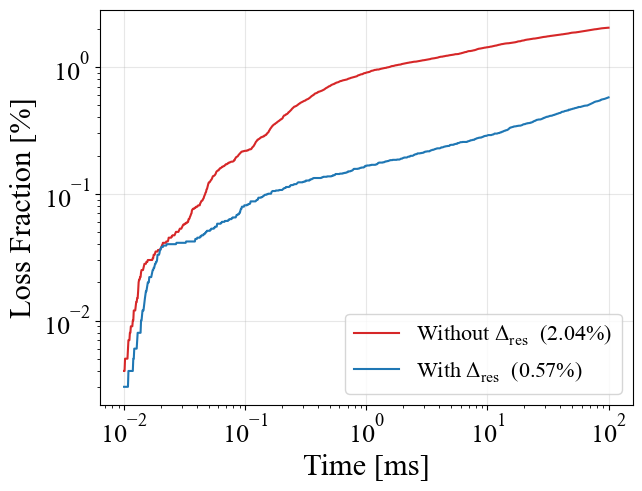

In [5]:
# --- figure (a): loss fraction vs time ---------------------------------------
fig_a, ax = plt.subplots(figsize=PANEL_SIZE)

for tag, path, label, color in configs:
    d = np.load(path)
    ax.loglog(d["loss_times"] * 1e3, d["loss_fraction"] * 100, color=color,
              label=f"{label}  ({d['loss_fraction'][-1] * 100:.2f}%)")

ax.set_xlabel("Time [ms]", **label_kw)
ax.set_ylabel("Loss Fraction [%]", **label_kw)
ax.legend(loc="lower right", fontsize=16)
ax.tick_params(labelsize=tick_labelsize - 1)
ax.grid(True, which="major", alpha=0.3)

apply_standard_axes(fig_a)
fig_a.savefig(os.path.join(OUTDIR, "bcrit_loss_time_scan60_62.pdf"), dpi=300)
fig_a.savefig(os.path.join(OUTDIR, "bcrit_loss_time_scan60_62.png"), dpi=300)
plt.show()


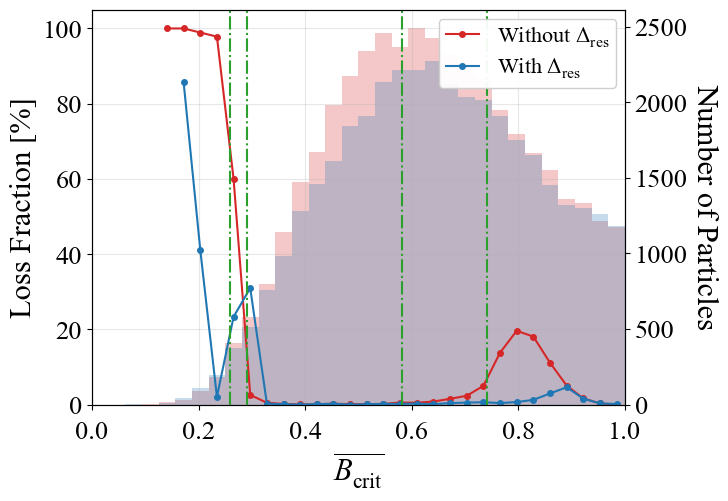

In [6]:
# --- figure (b): loss fraction vs normalized Bcrit ---------------------------
fig_b, ax = plt.subplots(figsize=PANEL_SIZE)
ax2 = ax.twinx()

bin_edges = np.linspace(0, 1, NBINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
report = {}

for tag, path, label, color in configs:
    d = np.load(path)
    Bcrit = d["Bcrit"]
    if norm == "global":
        lo = d["Bmin_s"].min()
        hi = d["Bmax_s"].max()
        trapped = Bcrit < hi          # trapping cut consistent with normalization
    else:
        lo = d["Bmin_at_particle"]
        hi = d["Bmax_at_particle"]
        trapped = Bcrit < hi
    v = np.clip((Bcrit[trapped] - (lo if np.isscalar(lo) else lo[trapped]))
                / ((hi if np.isscalar(hi) else hi[trapped])
                   - (lo if np.isscalar(lo) else lo[trapped])), 0, 1)
    lost = d["lost"][trapped]

    idx = np.clip(np.digitize(v, bin_edges) - 1, 0, NBINS - 1)
    counts = np.array([(idx == b).sum() for b in range(NBINS)])
    n_lost = np.array([lost[idx == b].sum() for b in range(NBINS)])
    with np.errstate(invalid="ignore", divide="ignore"):
        frac = np.where(counts > 0, n_lost / np.maximum(counts, 1), np.nan)
    report[tag] = (counts, n_lost, int(trapped.sum()))

    ax2.bar(bin_centers, counts, width=1.0 / NBINS, color=color, alpha=0.25, edgecolor="none")
    m = counts >= min_count
    ax.plot(bin_centers[m], 100 * frac[m], "o-", color=color, label=label, markersize=4)

for x in VLINES:
    ax.plot([x, x], [0, 110], "-.", color="tab:green")

ax.set_xlabel(r"$\overline{B_{\mathrm{crit}}}$", **label_kw)
ax.set_ylabel("Loss Fraction [%]", **label_kw)
ax2.set_ylabel("Number of Particles", rotation=270, labelpad=22, **label_kw)
ax.set_xlim([0, 1])
ax.set_ylim([0, 105])
# Compact legend flush to the axes top-right corner (past the green line at 0.742)
ax.legend(loc="upper right", fontsize=16, borderaxespad=0.4, framealpha=0.95,
          handlelength=1.5, labelspacing=0.3, borderpad=0.3)
ax.set_zorder(ax2.get_zorder() + 1)   # loss-fraction line drawn over the histogram
ax.patch.set_visible(False)
ax.tick_params(labelsize=tick_labelsize - 1)
ax.tick_params(axis="x", pad=8)
ax2.tick_params(labelsize=tick_labelsize - 1)
ax.grid(True, alpha=0.3)

apply_standard_axes(fig_b)
fig_b.savefig(os.path.join(OUTDIR, "bcrit_loss_bcrit_scan60_62.pdf"), dpi=300)
fig_b.savefig(os.path.join(OUTDIR, "bcrit_loss_bcrit_scan60_62.png"), dpi=300)
plt.show()


In [7]:
# --- per-bin report ----------------------------------------------------------
print(f"norm={norm}   trapped: scan60={report['scan60'][2]}  scan62={report['scan62'][2]}")
print(f"{'v':>7} {'s60 n':>7} {'s60 %':>7} {'s62 n':>7} {'s62 %':>7}")
c6, l6, _ = report["scan60"]
c2, l2, _ = report["scan62"]
for b in range(NBINS):
    if c6[b] or c2[b]:
        p6 = 100 * l6[b] / c6[b] if c6[b] else float("nan")
        p2 = 100 * l2[b] / c2[b] if c2[b] else float("nan")
        print(f"{bin_centers[b]:7.3f} {c6[b]:7d} {p6:7.1f} {c2[b]:7d} {p2:7.1f}")


norm=global   trapped: scan60=37911  scan62=41413
      v   s60 n   s60 %   s62 n   s62 %
  0.078       1   100.0       0     nan
  0.109       0     nan       4   100.0
  0.141       8   100.0      16   100.0
  0.172      42    85.7      32   100.0
  0.203     107    41.1      92    98.9
  0.234     193     2.1     184    97.8
  0.266     377    23.3     405    60.0
  0.297     513    31.0     581     2.6
  0.328     758     0.3     799     0.5
  0.359     986     0.1    1143     0.2
  0.391    1281     0.0    1471     0.1
  0.422    1458     0.1    1671     0.1
  0.453    1614     0.2    1981     0.3
  0.484    1843     0.0    2173     0.1
  0.516    1906     0.1    2338     0.1
  0.547    2131     0.2    2461     0.2
  0.578    2210     0.2    2368     0.5
  0.609    2210     0.3    2488     0.5
  0.641    2274     0.1    2426     0.8
  0.672    2120     0.4    2322     1.6
  0.703    2037     0.5    2258     2.3
  0.734    2014     0.6    2162     5.0
  0.766    1911     0.4    195

In [8]:
# --- passing-particle accounting ---------------------------------------------
# Trapped particles on the plot: Bcrit < Bmax_global  <=>  v < 1
# Passing / not shown:           Bcrit >= Bmax_global <=>  v >= 1
for tag, path, label, color in configs:
    d = np.load(path)
    Bcrit = d["Bcrit"]
    Bmin = d["Bmin_s"].min()
    Bmax = d["Bmax_s"].max()
    v = (Bcrit - Bmin) / (Bmax - Bmin)

    n_trapped = int((Bcrit < Bmax).sum())
    n_v_ge_1 = int((v >= 1).sum())
    n_total = len(Bcrit)

    print(f"{tag}  ({label})")
    print(f"  trapped on plot (v < 1):   {n_trapped:6d}")
    print(f"  with v >= 1 (not on plot): {n_v_ge_1:6d}")
    print(f"  total in simulation:       {n_total:6d}")
    print(f"  passing fraction:          {100 * n_v_ge_1 / n_total:.2f}%   (Bmax_global = {Bmax:.4f} T)")
    print()


scan62  (Without $\Delta_{\mathrm{res}}$)
  trapped on plot (v < 1):    41413
  with v >= 1 (not on plot):  58587
  total in simulation:       100000
  passing fraction:          58.59%   (Bmax_global = 6.5214 T)

scan60  (With $\Delta_{\mathrm{res}}$)
  trapped on plot (v < 1):    37911
  with v >= 1 (not on plot):  62089
  total in simulation:       100000
  passing fraction:          62.09%   (Bmax_global = 6.2190 T)

